## Validation exact-match failures — pipeline walkthrough

This notebook points at a sweep’s **`label_scores.json`** (default: **`preprocess_sweep_glm_broad_v5_charfb`**; change `SWEEP_STEM` in the first code cell to match your run, e.g. v4). It loads `validation_exact_failures.csv` for **`gray_x3_lanczos`**. It replays **frame → ROI → line boxes → crops → `gray_x3_lanczos` preprocessing** so you can see **where** labels diverge from OCR.

**Paths:** DICOM locations come from the chosen sweep’s `label_scores.json`. If files moved, set `ECHO_OCR_DICOM_ROOT` or edit `SWEEP_STEM` / `CONFIG_NAME` in the first code cell.

**Engine:** Uses **`glm-ocr`** with the same **`gray_x3_lanczos`** preprocess views as `sweep_preprocessing_headless.py` (`_build_preprocess_views`). If GLM cannot start, segmentation falls back to **no scout tokens** (visuals only; ordering can differ from the sweep).

**Notebook-only repair preview:** On failing lines, the inspection cell runs **adaptive char bands (from `full_match_char_dataset_builder`) → `per_char_slice_ocr_line`** (from `char_slice_ocr_experimental.py`) → optional **char CNN** — for evaluation only; **production `LineTranscriber` is unchanged** (char CNN only when enabled, as before).


In [1]:

from __future__ import annotations

import csv
import hashlib
import json
import os
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "app" / "pipeline" / "echo_ocr_pipeline.py").is_file():
            return p
    raise RuntimeError("Run this notebook from the Master repo.")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from app.validation.datasets import resolve_dataset_path

_ARTIFACT = REPO / "artifacts" / "ocr_redesign"
CONFIG_NAME = "gray_x3_lanczos"
SWEEP_STEM = "preprocess_sweep_glm_broad_v6"  # or preprocess_sweep_glm_broad_v4, etc.
LABEL_SCORES = _ARTIFACT / SWEEP_STEM / CONFIG_NAME / "label_scores.json"
if not LABEL_SCORES.is_file():
    raise FileNotFoundError(
        f"Missing label_scores.json — run a sweep into {_ARTIFACT}/<sweep>/{CONFIG_NAME}/ or fix SWEEP_STEM."
    )
FAILURES_CSV = LABEL_SCORES.parent.parent / "validation_exact_failures.csv"
print("Using sweep:", SWEEP_STEM, "|", LABEL_SCORES.relative_to(REPO))


def resolve_label_score_path(file_record: dict[str, object]) -> Path:
    return resolve_dataset_path(file_record, LABEL_SCORES)


ls = json.loads(LABEL_SCORES.read_text(encoding="utf-8"))
if FAILURES_CSV.is_file():
    with FAILURES_CSV.open(encoding="utf-8", newline="") as f:
        rows = list(csv.DictReader(f))
else:
    rows = []
    for fd in ls["file_details"]:
        if fd.get("split") != "validation":
            continue
        resolved_path = resolve_label_score_path(fd)
        fname = fd.get("file_name") or resolved_path.name
        for i, m in enumerate(fd.get("matches") or []):
            if m.get("full_match", True):
                continue
            rows.append(
                {
                    "file_name": fname,
                    "line_index_in_matches": str(i),
                    "expected_text": m.get("expected_text", ""),
                    "predicted_text": m.get("predicted_text") or "",
                    "line_match": str(m.get("line_match", "")),
                    "value_match": str(m.get("value_match", "")),
                    "label_match": str(m.get("label_match", "")),
                }
            )
    print("(built failure list from label_scores; run export_validation_failures.py to write CSV)")
path_by_name: dict[str, Path] = {}
for fd in ls["file_details"]:
    if fd.get("split") != "validation":
        continue
    resolved_path = resolve_label_score_path(fd)
    path_by_name[resolved_path.name] = resolved_path

extra_root = os.environ.get("ECHO_OCR_DICOM_ROOT", "").strip()
if extra_root:
    root = Path(extra_root).expanduser().resolve()
    for name in list(path_by_name.keys()):
        p = path_by_name[name]
        if not p.is_file():
            hits = list(root.rglob(name))
            if hits:
                path_by_name[name] = hits[0]

by_file: dict[str, list[dict[str, str]]] = defaultdict(list)
for row in rows:
    by_file[row["file_name"]].append(row)
by_file = dict(sorted(by_file.items()))

print("REPO:", REPO)
print("Failure rows:", len(rows), "| Unique DICOMs:", len(by_file))
for name in sorted(by_file.keys()):
    p = path_by_name.get(name)
    ok = p.is_file() if p else False
    print(f"  {name} ->", p if ok else (p, "MISSING"))


Using sweep: preprocess_sweep_glm_broad_v6 | artifacts/ocr_redesign/preprocess_sweep_glm_broad_v6/gray_x3_lanczos/label_scores.json
REPO: /home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/Master
Failure rows: 1 | Unique DICOMs: 1
  92290733_0004.dcm -> /home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/database_stage/files/p10/p10002430/s92290733/92290733_0004.dcm


In [2]:

from app.pipeline.ai_pipeline import PipelineConfig
from app.pipeline.layout.echo_ocr_box_detector import TopLeftBlueGrayBoxDetector, _color_match_mask
from app.pipeline.echo_ocr_pipeline import EchoOcrPipeline
from app.pipeline.ocr.ocr_engines import UnavailableOcrEngineError, build_engine
from app.tools.batch.sweep_preprocessing_headless import _broad_configs, _build_preprocess_views

detector = TopLeftBlueGrayBoxDetector()
sweep_cfg = next(c for c in _broad_configs() if c.name == "gray_x3_lanczos")
preprocess_views = _build_preprocess_views(sweep_cfg)

pipe: EchoOcrPipeline | None
pipe = None
try:
    pipe = EchoOcrPipeline(
        ocr_engine=build_engine("glm-ocr"),
        config=PipelineConfig(
            parameters={
                "ocr_engine": "glm-ocr",
                "requested_ocr_engine": "glm-ocr",
                "parser_mode": "off",
            }
        ),
    )
    pipe.ensure_components()
    pipe._line_transcriber.preprocess_views = preprocess_views
    print("Pipeline: glm-ocr +", sweep_cfg.name)
except (UnavailableOcrEngineError, Exception) as exc:
    print("GLM pipeline unavailable:", exc)
    print("Figures will use segmentation without scout tokens (fallback).")


The image processor of type `Glm46VImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Pipeline: glm-ocr + gray_x3_lanczos


### Per-slice OCR only (no char CNN)

This walkthrough does **not** load `char_model/`. Failing lines are cut into **N adaptive bands** (N = label length, spaces stripped), then the same **GLM** engine is run on each band. The **`POST_SLICE`** line tells you whether that still matches the label — use it to gate “needs human / uncertain” in a product, rather than a second ML head.


In [3]:
from pathlib import Path
import importlib

import torch
import app.pipeline.ocr.char_cnn_inference as _char_cnn_inference_mod
import app.pipeline.ocr.char_fallback as _char_fallback_mod

# Reload loader modules so notebook runs pick up recent code edits without a full kernel restart.
_char_fallback_mod = importlib.reload(_char_fallback_mod)
_char_cnn_inference_mod = importlib.reload(_char_cnn_inference_mod)
build_char_fallback_classifier = _char_cnn_inference_mod.build_char_fallback_classifier


def _resolve_char_model_dir(repo: Path) -> Path | None:
    root = repo / "artifacts" / "ocr_redesign" / "char_model"
    latest = root / "latest.txt"
    if latest.is_file():
        line = latest.read_text(encoding="utf-8").strip()
        p = Path(line)
        if not p.is_absolute():
            p = (repo / p).resolve()
        if (p / "model.pt").is_file():
            return p
    stamps = [p for p in root.iterdir() if p.is_dir() and p.name.endswith("Z") and (p / "model.pt").is_file()]
    stamps.sort(key=lambda q: q.name, reverse=True)
    return stamps[0] if stamps else None


_CHAR_DIR = _resolve_char_model_dir(REPO)
CHAR_FALLBACK_CLF = None
if _CHAR_DIR is not None:
    _cnn_dev = "cuda" if torch.cuda.is_available() else "cpu"
    try:
        CHAR_FALLBACK_CLF = build_char_fallback_classifier(_CHAR_DIR, prefer_cnn=True, device=_cnn_dev)
        meta = (_CHAR_DIR / "charset.json").read_text(encoding="utf-8")
        print("Char fallback CNN:", _CHAR_DIR, "| device:", _cnn_dev)
        print("Loaded metadata:", meta)
    except Exception as exc:
        print("Char fallback CNN load failed:", exc)
        print("Continuing without char model; the full-match slice visualization below does not need it.")
else:
    print("No char model under artifacts/ocr_redesign/char_model — run train_char_fallback_model.py first.")


Char fallback CNN: /home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/Master/artifacts/ocr_redesign/char_model/20260422T121550Z | device: cuda
Loaded metadata: {
  "charset": "0123456789./-%cmLAoEVIDT",
  "input_size": 24,
  "cnn_variant": "large"
}



In [4]:
from app.ocr.preprocessing import preprocess_gray_x3_lanczos

def _compact_chars(text: str) -> str:
    return "".join(ch for ch in str(text or "") if not ch.isspace())


def _stable_ratio(key: str) -> float:
    digest = hashlib.sha1(key.encode("utf-8")).hexdigest()
    value = int(digest[:8], 16)
    return value / float(0xFFFFFFFF)


def _gray_u8(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return image.astype(np.uint8, copy=False)
    if image.ndim == 3 and image.shape[-1] >= 3:
        return cv2.cvtColor(image[..., :3].astype(np.uint8, copy=False), cv2.COLOR_BGR2GRAY)
    if image.ndim == 3:
        return image[..., 0].astype(np.uint8, copy=False)
    raise ValueError(f"Unsupported image shape: {image.shape}")


def _binarize_for_dead_space_split(preprocessed_gray: np.ndarray) -> np.ndarray:
    """Match `notebooks/validation_failure_walkthrough.ipynb`: ink is white, background is black."""
    if preprocessed_gray.size == 0:
        return np.zeros((0, 0), dtype=np.uint8)

    g = preprocessed_gray
    if g.ndim == 3 and g.shape[-1] >= 3:
        g = cv2.cvtColor(g, cv2.COLOR_RGB2GRAY)
    elif g.ndim == 3 and g.shape[-1] == 1:
        g = g[..., 0]
    g = g.astype(np.uint8, copy=False)

    _, bw = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if float((bw > 0).mean()) > 0.5:
        bw = cv2.bitwise_not(bw)
    return bw


def _morph_close_horizontal(bw: np.ndarray, *, k: int) -> np.ndarray:
    k = int(max(1, k))
    if k % 2 == 0:
        k += 1
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, 1))
    return cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel)


def _gap_runs(ink_cols: np.ndarray, x0: int, x1: int, *, max_ink: int) -> list[tuple[int, int]]:
    """Maximal x-intervals [s, e) where every column has ink count <= max_ink."""
    runs: list[tuple[int, int]] = []
    s: int | None = None
    x0i, x1i = int(x0), int(x1)
    mx = int(max(0, max_ink))
    for x in range(x0i, x1i):
        if int(ink_cols[x]) <= mx:
            if s is None:
                s = x
        else:
            if s is not None:
                runs.append((s, x))
                s = None
    if s is not None:
        runs.append((s, x1i))
    return runs


def _gap_run_mid(s: int, e: int) -> int:
    return int(s + (e - s - 1) // 2)


def _dp_pick_increasing(
    values: list[int],
    targets: list[int],
) -> list[int]:
    """Pick len(targets) strictly increasing indices into values (by index) minimizing sum |values[j]-targets[t]|."""
    k = len(targets)
    m = len(values)
    if k == 0:
        return []
    if m < k:
        raise ValueError("need at least as many candidates as picks")
    inf = 10**18
    dp = [[inf] * m for _ in range(k)]
    prev_i = [[-1] * m for _ in range(k)]
    for r in range(m):
        dp[0][r] = abs(int(values[r]) - int(targets[0]))
    for t in range(1, k):
        for r in range(t, m):
            best = inf
            best_q = -1
            for q in range(t - 1, r):
                v = dp[t - 1][q] + abs(int(values[r]) - int(targets[t]))
                if v < best:
                    best = v
                    best_q = q
            dp[t][r] = best
            prev_i[t][r] = best_q
    best_r = min(range(k - 1, m), key=lambda r: dp[k - 1][r])
    chain = [best_r]
    for t in range(k - 1, 0, -1):
        chain.append(prev_i[t][chain[-1]])
    chain.reverse()
    return [int(values[j]) for j in chain]


def _choose_valley_cut(
    ink_cols_gap: np.ndarray,
    ink_cols_score: np.ndarray,
    bw_cross: np.ndarray,
    *,
    lo: int,
    hi: int,
    ideal: int,
    valley_radius: int | None = None,
    gap_max_ink: int = 0,
) -> int:
    """Pick a cut x in [lo, hi).

    Priority:
    1) Gap columns where ink count <= ``gap_max_ink`` (0 = true background), closest to ``ideal``.
    2) Otherwise fall back to a smoothed valley score on ``ink_cols_score``, penalizing vertical ink crossings.
       When ``valley_radius`` is set, the valley scan is limited to ``ideal ± valley_radius`` (clipped to
       ``[lo, hi)``); gap columns always use the full feasible strip.
    """
    if hi <= lo + 1:
        return int(max(lo, min(hi, ideal)))

    h = int(bw_cross.shape[0])
    mid = max(1, h // 2)
    top = bw_cross[:mid, :]
    bot = bw_cross[mid:, :]
    half_thr = max(1.0, 0.08 * float(h))

    gap = ink_cols_gap.astype(np.int32, copy=False)
    gmx = int(max(0, gap_max_ink))
    gap_cols = [x for x in range(int(lo), int(hi)) if int(gap[x]) <= gmx]
    if gap_cols:
        return int(min(gap_cols, key=lambda x: abs(int(x) - int(ideal))))

    ink = ink_cols_score.astype(np.float32, copy=False)
    ink_s = cv2.GaussianBlur(ink.reshape(1, -1), (0, 0), sigmaX=1.2).reshape(-1)

    v_lo, v_hi = int(lo), int(hi)
    if valley_radius is not None:
        r = int(max(0, valley_radius))
        v_lo = max(v_lo, int(ideal) - r)
        v_hi = min(v_hi, int(ideal) + r + 1)
        if v_hi <= v_lo + 1:
            v_lo, v_hi = int(lo), int(hi)

    best_x = int(v_lo)
    best_score = float("inf")
    for x in range(int(v_lo), int(v_hi)):
        col_ink = float(ink_s[x])
        top_ink = float((top[:, x] > 0).sum())
        bot_ink = float((bot[:, x] > 0).sum())
        cross_pen = 0.0
        if col_ink > 0.0 and top_ink >= half_thr and bot_ink >= half_thr:
            cross_pen = 0.55 * float(col_ink)

        local_lo = max(0, x - 3)
        local_hi = min(int(ink_s.shape[0]), x + 4)
        local_max = float(np.max(ink_s[local_lo:local_hi])) if local_hi > local_lo else 1.0
        depth = local_max - col_ink

        dist = abs(float(x - ideal))
        score = float(col_ink) + 0.08 * dist - 0.55 * float(depth) + float(cross_pen)

        if score < best_score:
            best_score = score
            best_x = int(x)

    return int(best_x)


def _adaptive_char_boxes(
    line_image: np.ndarray,
    expected_text: str,
    *,
    valley_search_frac: float = 0.4,
    close_kernel_px: int = 1,
    gap_max_ink_px: int = 1,
) -> tuple[np.ndarray, np.ndarray, list[dict[str, int | str]], list[int]]:
    chars = _compact_chars(expected_text)
    if not chars:
        return np.zeros((0, 0), dtype=np.uint8), np.zeros((0,), dtype=np.int32), [], []

    proc = preprocess_gray_x3_lanczos(line_image)
    bw0 = _binarize_for_dead_space_split(proc)
    bw = bw0 if int(close_kernel_px) <= 1 else _morph_close_horizontal(bw0, k=int(close_kernel_px))
    h, w = bw.shape[:2]
    # Gap detection should use the *unclosed* mask so 1px gaps stay gaps.
    ink_cols_gap = (bw0 > 0).sum(axis=0).astype(np.int32)
    # Score path can use a lightly closed mask for stability, but gaps come from `ink_cols_gap`.
    ink_cols_score = (bw > 0).sum(axis=0).astype(np.int32)
    active = ink_cols_gap > 0
    if active.any():
        xs = np.flatnonzero(active)
        x0, x1 = int(xs[0]), int(xs[-1]) + 1
    else:
        x0, x1 = 0, w

    n = len(chars)
    span = max(1, x1 - x0)
    avg_width = max(1.0, span / float(n))
    search_radius = max(2, int(round(avg_width * float(valley_search_frac))))
    k_cuts = n - 1
    uniform_ideals = [x0 + int(round(span * (j + 1) / float(n))) for j in range(k_cuts)]

    gap_mx = int(max(0, gap_max_ink_px))
    cand_cols: list[int] = []
    effective_gap_mx = gap_mx
    for mx_ink in (gap_mx, gap_mx + 1):
        runs = _gap_runs(ink_cols_gap, x0, x1, max_ink=int(mx_ink))
        cols: list[int] = []
        for s, e in runs:
            mid = _gap_run_mid(s, e)
            if int(x0) < int(mid) < int(x1):
                cols.append(int(mid))
        cand_cols = sorted(set(cols))
        effective_gap_mx = int(mx_ink)
        if len(cand_cols) >= k_cuts:
            break

    if k_cuts > 0 and len(cand_cols) >= k_cuts:
        dp_targets = _dp_pick_increasing(cand_cols, uniform_ideals)
    else:
        dp_targets = list(uniform_ideals)

    cuts: list[int] = []
    left_bound = x0
    for i in range(1, n):
        ideal = int(dp_targets[i - 1])
        rem = n - i
        lo = int(left_bound) + 1
        hi_cap = int(x1) - int(rem) + 1
        hi = max(lo + 1, min(int(w), hi_cap))
        cut = _choose_valley_cut(
            ink_cols_gap,
            ink_cols_score,
            bw,
            lo=lo,
            hi=hi,
            ideal=ideal,
            valley_radius=int(search_radius),
            gap_max_ink=int(effective_gap_mx),
        )
        cuts.append(int(cut))
        left_bound = int(cut)

    bounds = [int(x0), *cuts, int(x1)]
    boxes: list[dict[str, int | str]] = []
    for i, ch in enumerate(chars):
        sx0 = int(bounds[i])
        sx1 = max(sx0 + 1, int(bounds[i + 1]))
        sub = bw0[:, sx0:sx1]
        ys = np.flatnonzero(sub.any(axis=1))
        if ys.size:
            y0, y1 = int(ys[0]), int(ys[-1]) + 1
        else:
            y0, y1 = 0, h
        boxes.append(
            {
                "char_index": i,
                "char": ch,
                "x0": int(sx0),
                "y0": int(y0),
                "x1": int(sx1),
                "y1": int(y1),
            }
        )
    return proc, ink_cols_gap, boxes, cuts




def _adaptive_boxes_to_char_slices(
    bw0: np.ndarray, boxes: list[dict[str, int | str]]
) -> tuple:
    """Build CharSlice tuple in ``preprocess_gray_x3_lanczos`` (×3) coordinates."""
    from app.pipeline.transcription.dead_space_char_splitter import CharSlice

    h = int(bw0.shape[0])
    out: list[CharSlice] = []
    for b in boxes:
        sx0, sx1 = int(b["x0"]), int(b["x1"])
        y0, y1 = int(b["y0"]), int(b["y1"])
        sub = bw0[:, sx0:sx1] if sx1 > sx0 else np.zeros((h, 0), dtype=np.uint8)
        ink = float((sub > 0).mean()) if sub.size else 0.0
        out.append(
            CharSlice(
                x=sx0,
                y=y0,
                width=max(1, sx1 - sx0),
                height=max(1, y1 - y0),
                ink_density=ink,
            )
        )
    return tuple(out)


def _alnum_len(text: str) -> int:
    return sum(1 for ch in (text or "") if ch.isalnum())


def run_inspection(dicom_path: Path, fail_rows: list[dict[str, str]]) -> None:
    from app.io.dicom_loader import load_dicom_series
    from app.pipeline.echo_ocr_pipeline import (
        DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
        DEFAULT_SEGMENTATION_MODE,
        DEFAULT_TARGET_LINE_HEIGHT_PX,
    )
    from app.pipeline.layout.line_segmenter import LineSegmenter
    from app.pipeline.measurements.measurement_decoder import canonicalize_exact_line
    from app.pipeline.transcription.char_slice_ocr_experimental import per_char_slice_ocr_line
    from app.pipeline.transcription.line_transcriber import crop_segment

    series = load_dicom_series(dicom_path, load_pixels=True)
    frame = series.raw_frames[0]

    detection = detector.detect(frame)
    if not detection.present or detection.bbox is None:
        print("ROI not found for", dicom_path.name)
        return

    x, y, bw, bh = detection.bbox
    rgb = frame[..., :3].astype(np.int16)
    mask = _color_match_mask(rgb, detector.box_color, detector.color_tolerance).astype(np.uint8) * 255
    overlay = frame.copy()
    cv2.rectangle(overlay, (x, y), (x + bw, y + bh), (0, 255, 0), 2)

    roi = frame[y : y + bh, x : x + bw].copy()
    segmentation = None
    panel = None
    measurements = []

    if pipe is not None:
        _det, segmentation, _ocr, panel, measurements, _bbox = pipe.analyze_frame_with_debug(frame)
    else:
        segmenter = LineSegmenter(
            segmentation_mode=DEFAULT_SEGMENTATION_MODE,
            target_line_height_px=DEFAULT_TARGET_LINE_HEIGHT_PX,
            extra_left_pad_px=DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
        )
        segmentation = segmenter.segment(roi, tokens=None)

    usable_segments = list(segmentation.lines)
    line_crops = [crop_segment(roi, seg) for seg in usable_segments]
    match_ixs = sorted({int(r["line_index_in_matches"]) for r in fail_rows})
    match_to_panel_ix: dict[int, int] = {}
    for match_ix, measurement in enumerate(measurements):
        panel_ix = measurement.order_hint
        if panel_ix is None:
            continue
        panel_ix = int(panel_ix)
        if 0 <= panel_ix < len(usable_segments):
            match_to_panel_ix[match_ix] = panel_ix
    bad_panel_ix = {match_to_panel_ix[ix] for ix in match_ixs if ix in match_to_panel_ix}
    unmapped_match_ixs = [ix for ix in match_ixs if ix not in match_to_panel_ix]
    panel_to_match_ix = {panel_ix: match_ix for match_ix, panel_ix in match_to_panel_ix.items()}

    primary_ocr = None
    fallback_ocr = None
    if pipe is not None:
        oe = pipe.ocr_engine
        if hasattr(oe, "primary"):
            primary_ocr = oe.primary
            fallback_ocr = getattr(oe, "fallback", None)
        else:
            primary_ocr = oe

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.0, 1.2, 0.9])

    ax0 = fig.add_subplot(gs[0, :])
    ax0.imshow(frame)
    ax0.set_title(f"{dicom_path.name} - 1 Full frame")
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[1, 0])
    ax1.imshow(mask, cmap="gray")
    ax1.set_title("2a Max channel |Δ| to box color (<= tolerance = match)")
    ax1.axis("off")
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.imshow(overlay)
    ax2.set_title("2b ROI box")
    ax2.axis("off")
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.imshow(roi)
    ax3.set_title("3 Cropped ROI")
    ax3.axis("off")

    vis = roi.copy()
    for idx, line in enumerate(usable_segments):
        lx, ly, lw, lh = line.bbox
        col = (255, 64, 64) if idx in bad_panel_ix else (255, 0, 0)
        th = 2 if idx in bad_panel_ix else 1
        cv2.rectangle(vis, (lx, ly), (lx + lw, ly + lh), col, th)
        cv2.putText(
            vis,
            str(idx),
            (lx, max(0, ly - 2)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            col,
            1,
            cv2.LINE_AA,
        )
    ax4 = fig.add_subplot(gs[2, :])
    ax4.imshow(vis)
    ax4.set_title("4 Line boxes (thicker red = panel lines linked to failing CSV matches)")
    ax4.axis("off")

    plt.suptitle(dicom_path.name, fontsize=11)
    plt.tight_layout()
    plt.show()

    if unmapped_match_ixs:
        print(f"  warning: could not map match indexes to panel lines: {unmapped_match_ixs}")

    n = len(line_crops)
    if n == 0:
        print("  no measurement lines after segmentation")
    else:
        cols = min(4, n)
        rows = (n + cols - 1) // cols
        fig2, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 2.4 * rows))
        axes = np.atleast_1d(axes).ravel()
        for i, crop in enumerate(line_crops):
            axes[i].imshow(crop)
            title = f"Line {i}"
            if i in bad_panel_ix:
                title = f"FAIL {i}"
            axes[i].set_title(title, fontsize=8, color=("red" if i in bad_panel_ix else "black"))
            axes[i].axis("off")
        for j in range(n, len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"{dicom_path.name} - 5 Raw line crops", fontsize=10)
        plt.tight_layout()
        plt.show()

    print("--- Repair loop (failed lines): line OCR → adaptive bands + per-slice OCR + POST_SLICE verdict ---")
    for panel_ix in sorted(bad_panel_ix):
        if panel_ix >= len(line_crops):
            print(f"  panel line index {panel_ix} out of range (only {len(line_crops)} lines)")
            continue

        raw_line = line_crops[panel_ix]

        ocr_txt = ""
        line_src = ""
        if panel is not None and panel_ix < len(panel.lines):
            pl = panel.lines[panel_ix]
            ocr_txt = pl.text or ""
            line_src = pl.source or ""

        match_ix = panel_to_match_ix.get(panel_ix)
        expected_txt = ""
        predicted_txt = ""
        for row in fail_rows:
            if match_ix is not None and int(row["line_index_in_matches"]) == int(match_ix):
                expected_txt = row.get("expected_text", "")
                predicted_txt = row.get("predicted_text", "")
                break

        proc, _ink_gap, boxes, cuts = _adaptive_char_boxes(raw_line, str(expected_txt or ""))
        bw0 = _binarize_for_dead_space_split(proc)
        slices = _adaptive_boxes_to_char_slices(bw0, boxes) if boxes else tuple()

        slice_ocr_txt = ""
        slice_ocr_mean = 0.0
        slice_ocr_min = 0.0
        pconf: tuple = ()
        if slices and primary_ocr is not None:
            slice_ocr_txt, slice_ocr_mean, slice_ocr_min, pconf = per_char_slice_ocr_line(
                proc,
                slices,
                primary_engine=primary_ocr,
                fallback_engine=None,
                preprocessor=lambda g: g,
            )
        slice_ocr_txt = canonicalize_exact_line(slice_ocr_txt)
        exp_c = _compact_chars(str(expected_txt or ""))
        got_c = _compact_chars(str(slice_ocr_txt or ""))
        n_slices = len(slices)
        n_gold = len(exp_c)
        if not exp_c:
            verdict = "POST_SLICE: NO_GOLD (cannot compare)"
        elif not slices:
            verdict = "POST_SLICE: NO_BANDS (no ink or empty label)"
        elif n_gold != n_slices or len(got_c) != n_gold:
            verdict = (
                "POST_SLICE: LENGTH_MISMATCH  "
                f"bands={n_slices}  gold_compact={n_gold}  per_slice_compact_len={len(got_c)}"
            )
        elif exp_c == got_c:
            verdict = f"POST_SLICE: MATCH  ({n_gold} compact chars)"
        else:
            verdict = "POST_SLICE: STILL_WRONG (per-slice OCR ≠ label; same band count)"
        print(f"  panel line {panel_ix}: {verdict}  line_source={line_src!r}")
        print(f"    (1) line OCR (panel): {ocr_txt!r}")
        print(
            f"    (2) per-slice OCR:    {slice_ocr_txt!r}   "
            f"mean_conf={slice_ocr_mean:.3f}  min_conf={slice_ocr_min:.3f}"
        )
        if exp_c and got_c and len(exp_c) == len(got_c) and exp_c != got_c:
            chdiff = " · ".join(
                f"pos{j} {a!r}→{b!r}" for j, (a, b) in enumerate(zip(exp_c, got_c)) if a != b
            )
            print(f"    per-char vs gold:  {chdiff}")
        print(f"    compact: gold={exp_c!r}  per-slice={got_c!r}")
        low_ink_i = [i for i, s in enumerate(slices) if float(getattr(s, "ink_density", 0.0)) < 0.02]
        if low_ink_i:
            print(f"    low-ink band idx (suspicious): {low_ink_i[:24]!r}{'…' if len(low_ink_i) > 24 else ''}")
        if pconf:
            lo = [i for i, t in enumerate(pconf) if float(t) < 0.35]
            if lo:
                print(f"    per-slice conf <0.35 at idx: {lo[:24]!r}{'…' if len(lo) > 24 else ''}")
        print(f"    expected (label):      {expected_txt!r}")
        print(f"    predicted (eval file): {predicted_txt!r}")

        cut_cols: list[int] = []
        if boxes:
            cut_cols.append(int(boxes[0]["x0"]))
        cut_cols.extend(int(c) for c in cuts)
        if boxes:
            cut_cols.append(int(boxes[-1]["x1"]))

        fig3, axs = plt.subplots(1, 2, figsize=(12, 2.8))
        axs[0].imshow(proc, cmap="gray")
        axs[0].set_title(f"Panel line {panel_ix} preprocess_gray_x3_lanczos", fontsize=8)
        axs[0].axis("off")

        axs[1].imshow(bw0, cmap="gray")
        for cx in cut_cols:
            axs[1].axvline(cx, color="cyan", linewidth=1.0, alpha=0.7)
        axs[1].set_title(
            f"Binarized + cut columns (adaptive: {n_slices} chars, {len(cuts)} internal cuts), ×3 line space",
            fontsize=8,
        )
        axs[1].axis("off")
        plt.tight_layout()
        plt.show()


    print("--- Label CSV vs OCR line text ---")
    for row in fail_rows:
        match_ix = int(row["line_index_in_matches"])
        exp = row["expected_text"]
        pred = row["predicted_text"]
        panel_ix = match_to_panel_ix.get(match_ix)
        ocr_line = ""
        if panel is not None and panel_ix is not None and panel_ix < len(panel.lines):
            ocr_line = panel.lines[panel_ix].text or ""
        print(f"  match index {match_ix}:")
        print(f"    panel line index: {panel_ix if panel_ix is not None else 'unavailable'}")
        print(f"    expected (label):  {exp!r}")
        print(f"    predicted (eval):  {pred!r}")
        print(f"    OCR line (panel): {ocr_line!r}")
        print(
            f"    char lens (alnum): expected={_alnum_len(exp)}, predicted={_alnum_len(pred)}, ocr={_alnum_len(ocr_line)}"
        )
    print()


## Dataset Note

The full-match dataset-building exploration was moved out of this notebook.

Use the dedicated full-match dataset notebook for:
- building per-character crops from real line images
- visual slice QA
- exporting `train_manifest.json` / `val_manifest.json`

This walkthrough stays focused on the current validation failures and optional char-CNN evaluation on those failures.

In [5]:
# Dataset-building exploration moved to the dedicated full-match dataset notebook.

## Run all failure files

Set `ONLY_NAMES` to restrict to a subset (e.g. one study for a meeting).

/home/warre/Documents/howest/Semester_5/Stage/StageOpdracht/database_stage/files/p10/p10002430/s92290733/92290733_0004.dcm


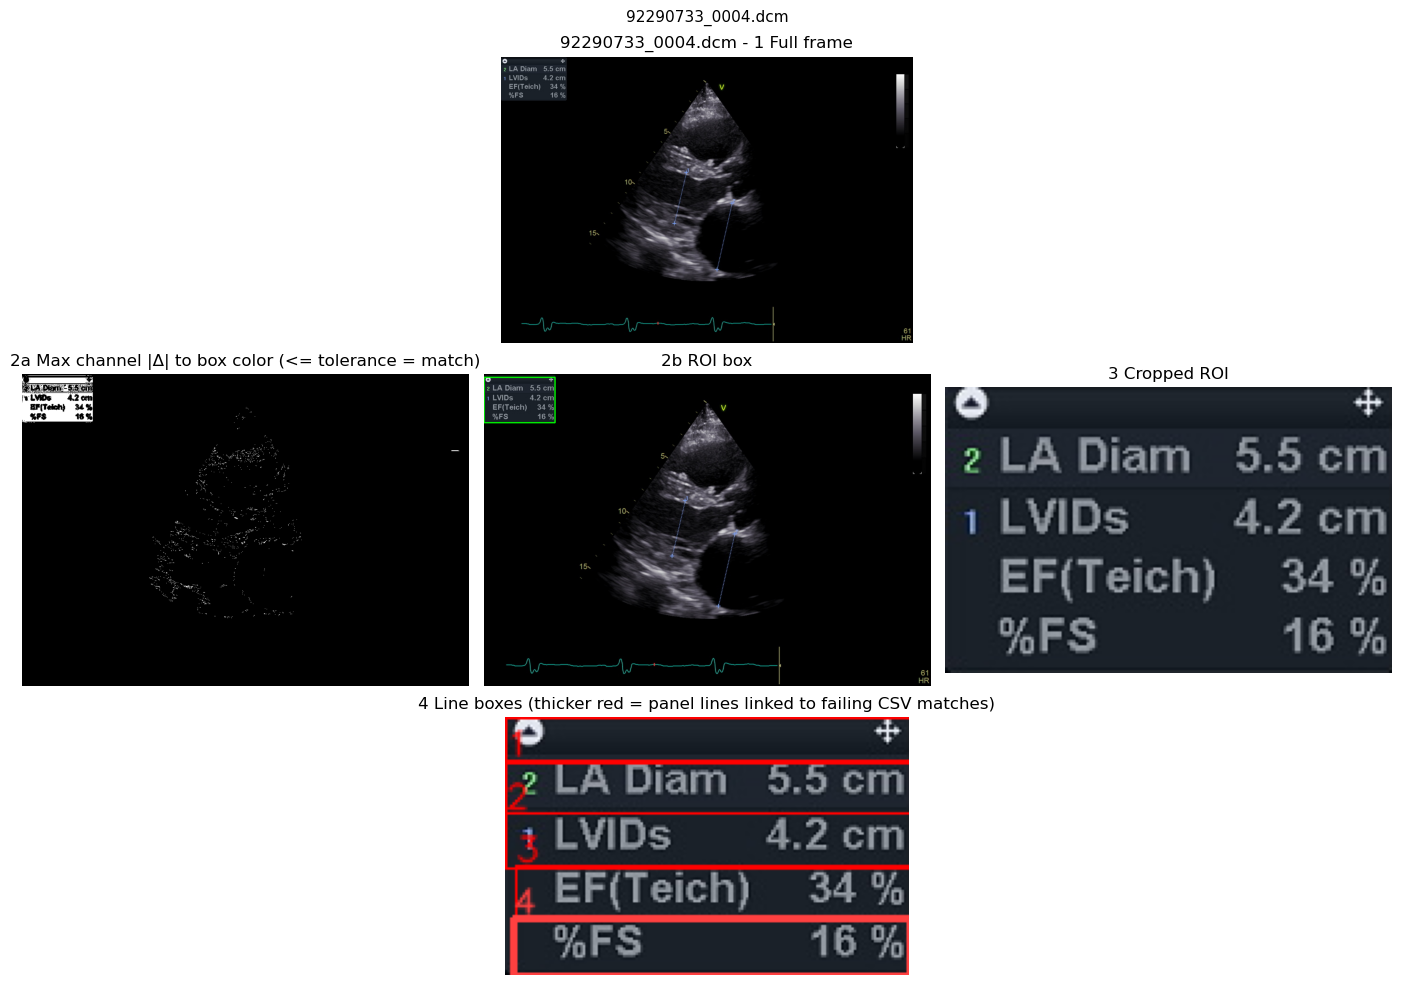

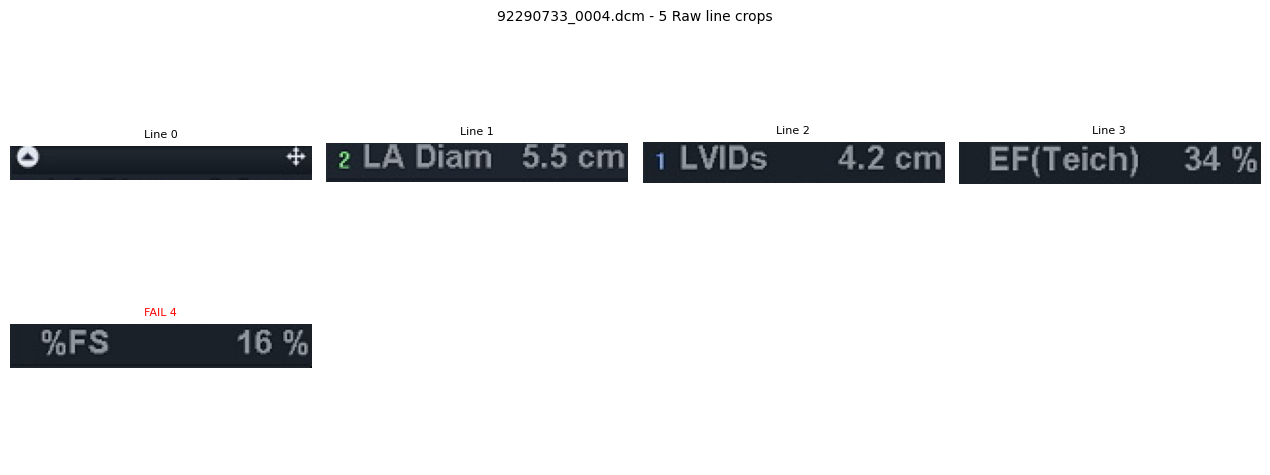

--- Repair loop (failed lines): line OCR → adaptive bands + per-slice OCR + POST_SLICE verdict ---
  panel line 4: POST_SLICE: MATCH  (6 compact chars)  line_source='primary_family_repair'
    (1) line OCR (panel): '%FS 6 %'
    (2) per-slice OCR:    '%FS16 %'   mean_conf=0.990  min_conf=0.990
    compact: gold='%FS16%'  per-slice='%FS16%'
    expected (label):      '%FS 16 %'
    predicted (eval file): '%FS 6 %'


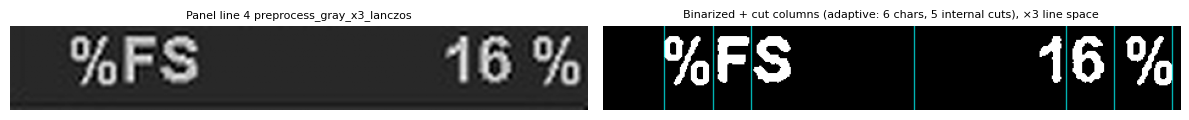

--- Label CSV vs OCR line text ---
  match index 3:
    panel line index: 4
    expected (label):  '%FS 16 %'
    predicted (eval):  '%FS 6 %'
    OCR line (panel): '%FS 6 %'
    char lens (alnum): expected=4, predicted=3, ocr=3



In [6]:

ONLY_NAMES: set[str] | None = None  # e.g. {"92290733_0035.dcm"}

names = sorted(by_file.keys())
if ONLY_NAMES is not None:
    names = [n for n in names if n in ONLY_NAMES]

for name in names:
    p = path_by_name.get(name)
    if p is None or not p.is_file():
        print("Skip (path missing):", name, p)
        continue
    print("=" * 72)
    print(p)
    run_inspection(p, by_file[name])


## Trained char CNN on current failures

This section is separate from the main walkthrough on purpose.

It applies the trained char CNN to the currently failing lines, using the **same adaptive vertical bands** as the inspection cell (``full_match`` logic on the preprocessed line), and prints a short summary per line:
- expected text, eval-file OCR prediction, char-CNN prediction, and **per-slice (vertical-split) OCR** (same GLM pass as the repair loop)
- the raw character crop grid (titles still show per-char label and confidence)

If no trained model is available, this section prints a message and exits cleanly.


=== 92290733_0004.dcm ===
  match 3 | panel 4
    expected:                          '%FS 16 %'
    predicted (ocr, eval file):         '%FS 6 %'
    predicted (char cnn):               '%E416 %'
    predicted (ocr, vertical split):  '%FS16 %'
    vertical split vs label (non-space chars):  match  '%FS16%'


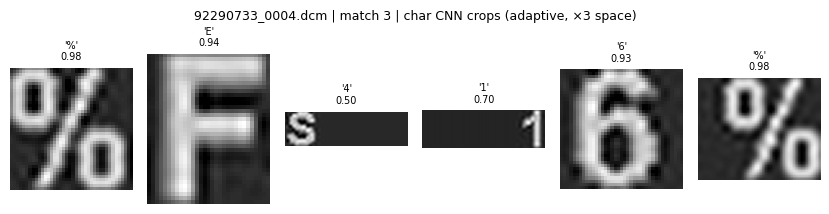

In [7]:
from app.pipeline.measurements.measurement_decoder import canonicalize_exact_line
from app.pipeline.transcription.line_transcriber import crop_segment


def _line_compact(text: str) -> str:
    """Same as the walkthrough’s ``_compact_chars``: drop spaces for label comparison."""
    return "".join(ch for ch in str(text or "") if not ch.isspace())


ONLY_NAMES_CNN: set[str] | None = None  # e.g. {"92290733_0004.dcm"}


def run_trained_char_eval(dicom_path: Path, fail_rows: list[dict[str, str]]) -> None:
    _clf = globals().get("CHAR_FALLBACK_CLF")
    if _clf is None:
        print("No trained char CNN loaded; skip char evaluation.")
        return

    from app.io.dicom_loader import load_dicom_series
    from app.pipeline.echo_ocr_pipeline import (
        DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
        DEFAULT_SEGMENTATION_MODE,
        DEFAULT_TARGET_LINE_HEIGHT_PX,
    )
    from app.pipeline.layout.line_segmenter import LineSegmenter
    from app.pipeline.transcription.char_slice_ocr_experimental import per_char_slice_ocr_line

    series = load_dicom_series(dicom_path, load_pixels=True)
    frame = series.raw_frames[0]
    detection = detector.detect(frame)
    if not detection.present or detection.bbox is None:
        print("ROI not found for", dicom_path.name)
        return

    x, y, bw, bh = detection.bbox
    roi = frame[y : y + bh, x : x + bw].copy()

    segmenter = LineSegmenter(
        segmentation_mode=DEFAULT_SEGMENTATION_MODE,
        target_line_height_px=DEFAULT_TARGET_LINE_HEIGHT_PX,
        extra_left_pad_px=DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
    )
    segmentation = segmenter.segment(roi, tokens=None)
    measurements = []
    if pipe is not None:
        try:
            _det, segmentation, _ocr, _panel, measurements, _bbox = pipe.analyze_frame_with_debug(frame)
        except Exception as exc:
            print("Pipeline mapping unavailable, using raw segmentation:", exc)
            segmentation = segmenter.segment(roi, tokens=None)
            measurements = []

    usable_segments = list(segmentation.lines)
    match_to_panel_ix: dict[int, int] = {}
    for match_ix, measurement in enumerate(measurements):
        hint = getattr(measurement, "order_hint", None)
        if hint is None:
            continue
        hint = int(hint)
        if 0 <= hint < len(usable_segments):
            match_to_panel_ix[int(match_ix)] = hint

    primary_ocr = None
    if pipe is not None:
        oe = pipe.ocr_engine
        if hasattr(oe, "primary"):
            primary_ocr = oe.primary
        else:
            primary_ocr = oe

    print(f"=== {dicom_path.name} ===")
    for row in fail_rows:
        match_ix = int(row["line_index_in_matches"])
        panel_ix = match_to_panel_ix.get(match_ix, match_ix)
        if not (0 <= panel_ix < len(usable_segments)):
            print(f"  match {match_ix}: panel index {panel_ix} out of range")
            continue

        raw_line = crop_segment(roi, usable_segments[panel_ix])
        expected_txt = str(row.get("expected_text", "") or "")
        proc, _ink, boxes, _ = _adaptive_char_boxes(raw_line, expected_txt)
        bw0 = _binarize_for_dead_space_split(proc)
        slices = _adaptive_boxes_to_char_slices(bw0, boxes) if boxes else tuple()
        if not slices:
            print(f"  match {match_ix}: no adaptive slices (empty label text or no ink span)")
            continue

        fb = _clf.predict(proc, slices)
        cnn_line = canonicalize_exact_line(fb.text)
        pchars = getattr(fb, "per_char_prediction", ()) or ()

        if primary_ocr is not None and slices:
            split_ocr, _, _, _ = per_char_slice_ocr_line(
                proc,
                slices,
                primary_engine=primary_ocr,
                fallback_engine=None,
                preprocessor=lambda g: g,
            )
            split_ocr = canonicalize_exact_line(split_ocr)
        else:
            split_ocr = "(unavailable)"

        print(f"  match {match_ix} | panel {panel_ix}")
        print(f"    expected:                          {row.get('expected_text', '')!r}")
        print(f"    predicted (ocr, eval file):         {row.get('predicted_text', '')!r}")
        print(f"    predicted (char cnn):               {cnn_line!r}")
        print(f"    predicted (ocr, vertical split):  {split_ocr!r}")
        if split_ocr != "(unavailable)":
            exp_c = _line_compact(str(row.get("expected_text", "") or ""))
            sp_c = _line_compact(str(split_ocr or ""))
            if exp_c and exp_c == sp_c:
                print(f"    vertical split vs label (non-space chars):  match  {exp_c!r}")

        disp = proc
        nch = len(slices)
        cols = min(12, nch)
        rows_n = (nch + cols - 1) // cols
        fig, axes = plt.subplots(rows_n, cols, figsize=(1.4 * cols, 2.2 * rows_n))
        axes = np.atleast_1d(axes).ravel()
        for k, sl in enumerate(slices):
            x1 = max(0, int(sl.x))
            y1 = max(0, int(sl.y))
            x2 = min(disp.shape[1], x1 + int(sl.width))
            y2 = min(disp.shape[0], y1 + int(sl.height))
            crop = disp[y1:y2, x1:x2] if y2 > y1 and x2 > x1 else np.zeros((1, 1), dtype=np.uint8)
            axes[k].imshow(crop, cmap="gray")
            lbl = pchars[k] if k < len(pchars) else "?"
            conf = float(fb.per_char_confidence[k]) if k < len(fb.per_char_confidence) else 0.0
            axes[k].set_title(f"{lbl!r}\n{conf:.2f}", fontsize=7)
            axes[k].axis("off")
        for ax in axes[nch:]:
            ax.axis("off")
        plt.suptitle(f"{dicom_path.name} | match {match_ix} | char CNN crops (adaptive, ×3 space)", fontsize=9)
        plt.tight_layout()
        plt.show()


names_cnn = sorted(by_file.keys())
if ONLY_NAMES_CNN is not None:
    names_cnn = [n for n in names_cnn if n in ONLY_NAMES_CNN]

for name in names_cnn:
    p2 = path_by_name.get(name)
    if p2 is None or not p2.is_file():
        print("Skip (path missing):", name, p2)
        continue
    run_trained_char_eval(p2, by_file[name])
